In [1]:
import numpy as np
import matplotlib.pyplot as plt
from utils.lorenz63 import lorenz, lorenz_variational

### Compute eigenvalues of fixed points linearized evolution in Lorenz-63

In [2]:
# helper functions 

def fixed_points(sigma, rho, beta):
    """Three fixed points of Lorenz-63."""
    x0 = np.array([0.0, 0.0, 0.0])
    if rho<1-1e-6: return [x0]
    r  = np.sqrt(max(beta * (rho - 1), 0.0))
    xp = np.array([ r,  r, rho - 1])
    xm = np.array([-r, -r, rho - 1])
    return [x0, xp, xm]

def jacobian(fp, sigma, rho, beta):
    """Jacobian of Lorenz-63 at fixed point fp = (x, y, z)."""
    x, y, z = fp
    return np.array([
        [-sigma,   sigma,  0    ],
        [rho - z, -1,     -x   ],
        [y,        x,     -beta],
    ])

def sorted_eigs(fp, sigma, rho, beta):
    """Eigenvalues sorted by real part (descending)."""
    ev = np.linalg.eigvals(jacobian(fp, sigma, rho, beta))
    return ev[np.argsort(-ev.real)]

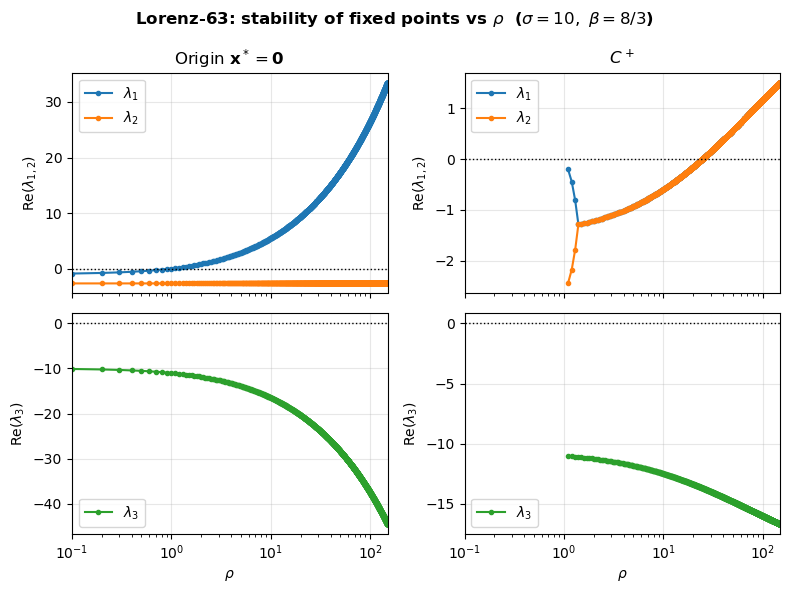

In [3]:
sigma = 10.0
beta  = 8.0 / 3.0
rhos  = np.arange(0.1, 150, 0.1)

E0, Ep = [], []

for rho in rhos:
    points = fixed_points(sigma, rho, beta)
    E0.append(sorted_eigs(points[0], sigma, rho, beta))
    if rho > 1:
        Ep.append(sorted_eigs(points[1], sigma, rho, beta))
    else:
        Ep.append([np.nan + 0j]*3)

E0, Ep = map(np.array, [E0, Ep])

fig, axes = plt.subplots(2, 2, figsize=(8, 6), sharex=True)
fig.suptitle(
    r"Lorenz-63: stability of fixed points vs $\rho$  ($\sigma=10,\ \beta=8/3$)",
    fontsize=12, fontweight="bold"
)

col_data = [(E0, r"Origin $\mathbf{x}^*=\mathbf{0}$"),
            (Ep, r"$C^+$")]

for col, (E, title) in enumerate(col_data):
    ax_re = axes[0, col]
    ax_r3 = axes[1, col]

    for i in range(2):
        ax_re.plot(rhos, E[:, i].real, '.-', color=f"C{i}", label=rf"$\lambda_{i+1}$")

    ax_r3.plot(rhos, E[:, 2].real, '.-',color="C2", label=r"$\lambda_3$")

    for ax in (ax_re, ax_r3):
        ax.axhline(0, color="k", lw=1, ls=":")
        ax.grid(True, alpha=0.3)
        ax.legend()
        ax.semilogx()

    ax_re.set_title(title)
    ax_re.set_xlim(rhos[0], rhos[-1])
    ax_re.set_ylabel(r"Re$(\lambda_{1,2})$")
    ax_r3.set_ylabel(r"Re$(\lambda_3)$")
    ax_r3.set_xlabel(r"$\rho$")
    ax_r3.set_xlim(rhos[0], rhos[-1])

plt.tight_layout()

### Plot phase portrait (many trajectories)

[stable fixed point] Trajectory 1/7. Lyapunov exponents: [ -0.42596662  -3.06001113 -10.18096225]
[stable fixed point] Trajectory 2/7. Lyapunov exponents: [ -0.42596662  -3.03426292 -10.20671046]
[stable fixed point] Trajectory 3/7. Lyapunov exponents: [ -0.42596662  -3.03489687 -10.20607652]
[stable fixed point] Trajectory 4/7. Lyapunov exponents: [ -0.42596662  -3.05574862 -10.18522477]
[stable fixed point] Trajectory 5/7. Lyapunov exponents: [ -0.42596662  -3.04015561 -10.20081777]
[stable fixed point] Trajectory 6/7. Lyapunov exponents: [ -0.42596662  -3.17005622 -10.07091717]
[stable fixed point] Trajectory 7/7. Lyapunov exponents: [ -0.42596662  -3.07684534 -10.16412804]


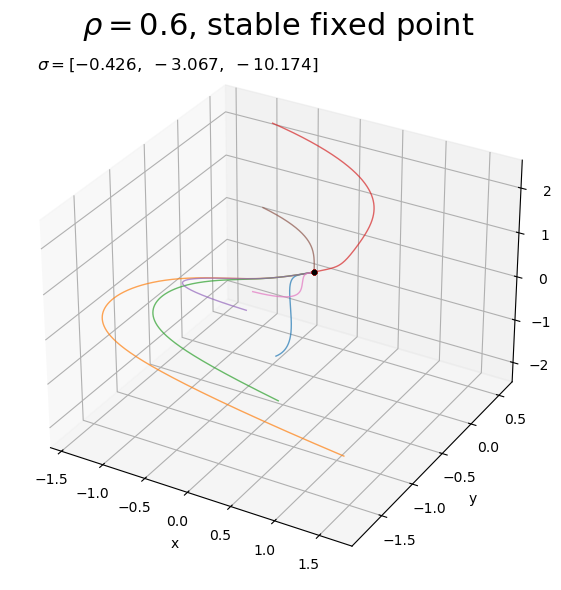

[2 stable nodes] Trajectory 1/7. Lyapunov exponents: [ -0.84593064  -1.78662634 -11.03438302]
[2 stable nodes] Trajectory 2/7. Lyapunov exponents: [ -0.84593064  -1.78662634 -11.03438302]
[2 stable nodes] Trajectory 3/7. Lyapunov exponents: [ -0.84593064  -1.78662634 -11.03438302]
[2 stable nodes] Trajectory 4/7. Lyapunov exponents: [ -0.84593064  -1.78662634 -11.03438302]
[2 stable nodes] Trajectory 5/7. Lyapunov exponents: [ -0.84593064  -1.78662634 -11.03438302]
[2 stable nodes] Trajectory 6/7. Lyapunov exponents: [ -0.84593064  -1.78662634 -11.03438302]
[2 stable nodes] Trajectory 7/7. Lyapunov exponents: [ -0.84593064  -1.78662634 -11.03438302]


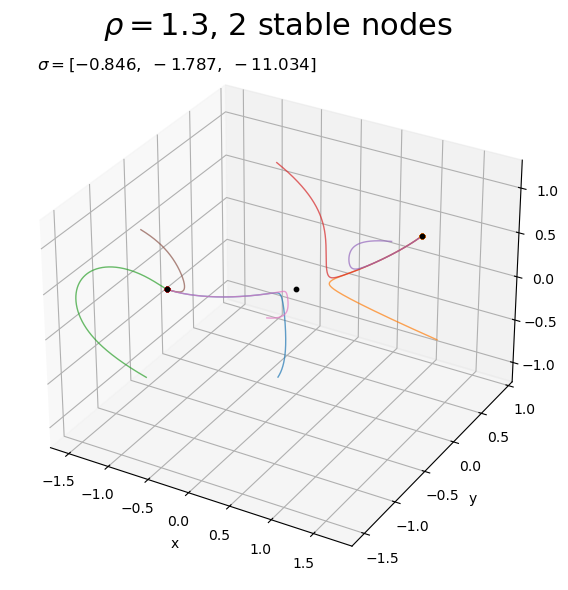

[2 stable foci] Trajectory 1/7. Lyapunov exponents: [ -0.59676778  -0.61429066 -12.45588156]
[2 stable foci] Trajectory 2/7. Lyapunov exponents: [ -0.59676778  -0.61429066 -12.45588156]
[2 stable foci] Trajectory 3/7. Lyapunov exponents: [ -0.59676778  -0.61429066 -12.45588156]
[2 stable foci] Trajectory 4/7. Lyapunov exponents: [ -0.59676778  -0.61429066 -12.45588156]
[2 stable foci] Trajectory 5/7. Lyapunov exponents: [ -0.59676778  -0.61429066 -12.45588156]
[2 stable foci] Trajectory 6/7. Lyapunov exponents: [ -0.59676778  -0.61429066 -12.45588156]
[2 stable foci] Trajectory 7/7. Lyapunov exponents: [ -0.59676778  -0.61429066 -12.45588156]


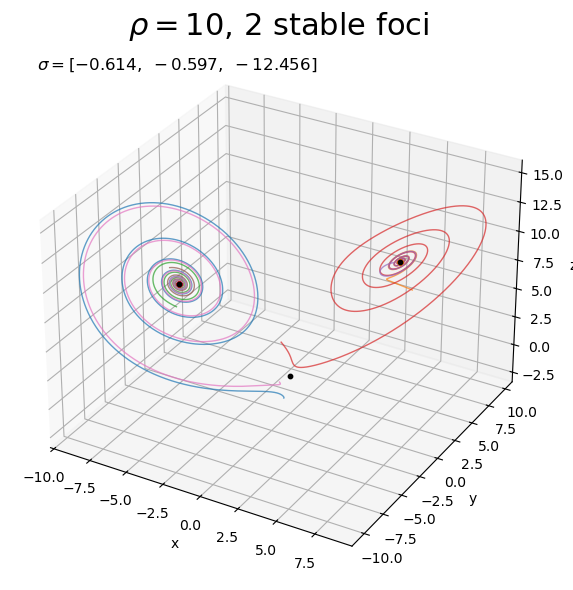

[stable limit cycle] Trajectory 1/7. Lyapunov exponents: [  0.0205408   -0.68023283 -13.00724798]
[stable limit cycle] Trajectory 2/7. Lyapunov exponents: [ 8.16508755e-03 -6.53244118e-01 -1.30218610e+01]
[stable limit cycle] Trajectory 3/7. Lyapunov exponents: [-1.12222183e-02 -7.06592226e-01 -1.29491256e+01]
[stable limit cycle] Trajectory 4/7. Lyapunov exponents: [-1.11931555e-02 -7.06510122e-01 -1.29492367e+01]
[stable limit cycle] Trajectory 5/7. Lyapunov exponents: [ 1.33467455e-03 -6.92678355e-01 -1.29755963e+01]
[stable limit cycle] Trajectory 6/7. Lyapunov exponents: [ -0.02832505  -0.7336938  -12.90492115]
[stable limit cycle] Trajectory 7/7. Lyapunov exponents: [ -0.0277846  -0.7222448 -12.9169106]


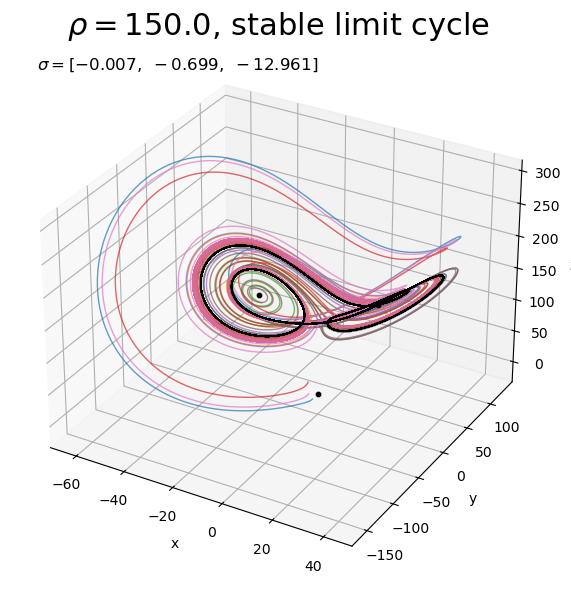

[chaotic attractor] Trajectory 1/7. Lyapunov exponents: [  0.91340234  -0.08699646 -14.49334588]
[chaotic attractor] Trajectory 2/7. Lyapunov exponents: [  0.89701186  -0.01633366 -14.54761821]
[chaotic attractor] Trajectory 3/7. Lyapunov exponents: [  0.91373095  -0.01901078 -14.56166017]
[chaotic attractor] Trajectory 4/7. Lyapunov exponents: [  0.93765167  -0.08705778 -14.5175339 ]
[chaotic attractor] Trajectory 5/7. Lyapunov exponents: [  0.93409924  -0.03934085 -14.56169839]
[chaotic attractor] Trajectory 6/7. Lyapunov exponents: [  0.92555829  -0.03414547 -14.55835282]
[chaotic attractor] Trajectory 7/7. Lyapunov exponents: [  0.87524719  -0.01989545 -14.52229174]


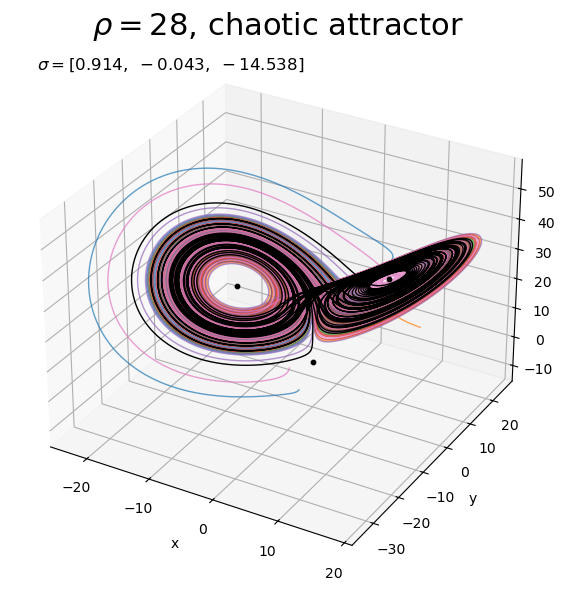

In [4]:
cases = [
    (0.6,   1.,  'stable fixed point'),
    (1.3,   0.5, '2 stable nodes'),
    (10,    1.,  '2 stable foci'),
    #(99.65, 5.,  'stable limit cycles'),
    (150., 5.,  'stable limit cycle'),
    (28,    5.,  'chaotic attractor'),
]

n_trajectories = 7
beta, sigma = 8.0/3.0, 10.
out_times = np.arange(0, 100, 0.001)
t_transient = 50

for rho, init_spread, title in cases:
    points = list(fixed_points(sigma, rho, beta))
    np.random.seed(2)
    trajectories, attractors, lyapunov_exponents = [], [], []

    for n in range(n_trajectories):
        init_state = points[n % len(points)] + init_spread * np.random.normal(size=3)
        out, exponents = lorenz_variational(time_series=out_times, init_state=list(init_state),
                                            parameters=[rho, beta, sigma], t_transient=t_transient)
        trajectories.append(out[out_times < 50])
        attractors.append(out[out_times > 50])
        lyapunov_exponents.append(exponents)
        print(f"[{title}] Trajectory {n+1}/{n_trajectories}. Lyapunov exponents: {np.sort(exponents)[::-1]}")

    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(111, projection='3d')
    ax.set_title(f"$\\rho={rho}$, {title}", fontsize=22)

    for traj in trajectories:
        ax.plot(traj[:, 0], traj[:, 1], traj[:, 2], lw=1, alpha=0.7)
    
    if rho > 25:
        traj=attractors[0]
        ax.plot(traj[:, 0], traj[:, 1], traj[:, 2], '-k', lw=1)
    else:
        for traj in attractors:
            ax.plot(traj[:, 0], traj[:, 1], traj[:, 2], '.-', lw=1)
    
    for fp in points:
        ax.scatter(*fp, c='k', s=10, zorder=5)

    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_zlabel('z')

    mean_le = np.mean(lyapunov_exponents, axis=0)
    ax.text2D(0.05, 0.95, f"$\\sigma = [{mean_le[0]:.3f},\\ {mean_le[1]:.3f},\\ {mean_le[2]:.3f}]$",
              transform=ax.transAxes, fontsize=12)
    plt.tight_layout()
    plt.savefig(f"figures/lorenz63_rho{rho}.png", dpi=300)
    plt.show()